# Project 2 (Proportion) Notebook (R): Estimation from a Random Sample  
**Question:** What proportion of CA high schools are **more than 50 years old** (in 2024)?

This notebook walks through:
1. Enter your simple random sample of school ages  
2. Create a binary variable: `old50` = TRUE if age > 50  
3. Show a bar plot of the data  
4. Report **count (x)**, **sample size (n)**, and **sample proportion (p-hat)**  
5. Compute a **95% confidence interval** for the population proportion **with a finite population correction (FPC)**  
6. Compute the interval a second way using the higher-level `survey` package


## Quick function summary (new functions used)

### Base R
- `length(x)` — sample size \(n\)  
- `sum(x)` — counts TRUEs (when `x` is logical)  
- `mean(x)` — proportion TRUE (when `x` is logical), i.e., \(\hat p\)

### ggplot2 (plot)
- `geom_bar()` — bar plot of counts for a categorical/binary variable

### Inference helpers
- `qnorm(0.975)` — the 97.5th percentile of the standard normal (for a 95% CI, \(z^*\))


## Step 0 — Install/load packages

We will use:
- **ggplot2** for the bar plot  
- **survey** for a high-level CI that supports **finite population correction**


In [ ]:
# Install packages if needed (uncomment if you don't have them)
# install.packages("ggplot2")
install.packages("survey")

library(ggplot2)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RcppArmadillo’




## Step 1 — Enter your sample ages and the population size

**Population (N):** all CA high schools in the directory (example: `N = 1617`)  
**Sample (ages):** the ages (in years, in 2024) of your randomly selected schools

**Action:** Replace `c()` below with your sample ages.


In [ ]:
ages <- c(12, 58, 41, 5, 33, 19, 72, 28, 14, 73)
N <- 1617

length(ages)  # n


[1] 10

## Step 2 — Create the binary variable: age > 50

We define:
- `old50 = TRUE` if the school's age is **more than 50 years**
- `old50 = FALSE` otherwise


In [ ]:
old50 <- ages > 50
old50


[1] FALSE  TRUE FALSE FALSE FALSE FALSE  TRUE FALSE FALSE  TRUE

## Step 3 — Bar plot of the data (counts)

This plot shows how many sampled schools are:
- **Older than 50 years** (TRUE)
- **50 years or younger** (FALSE)


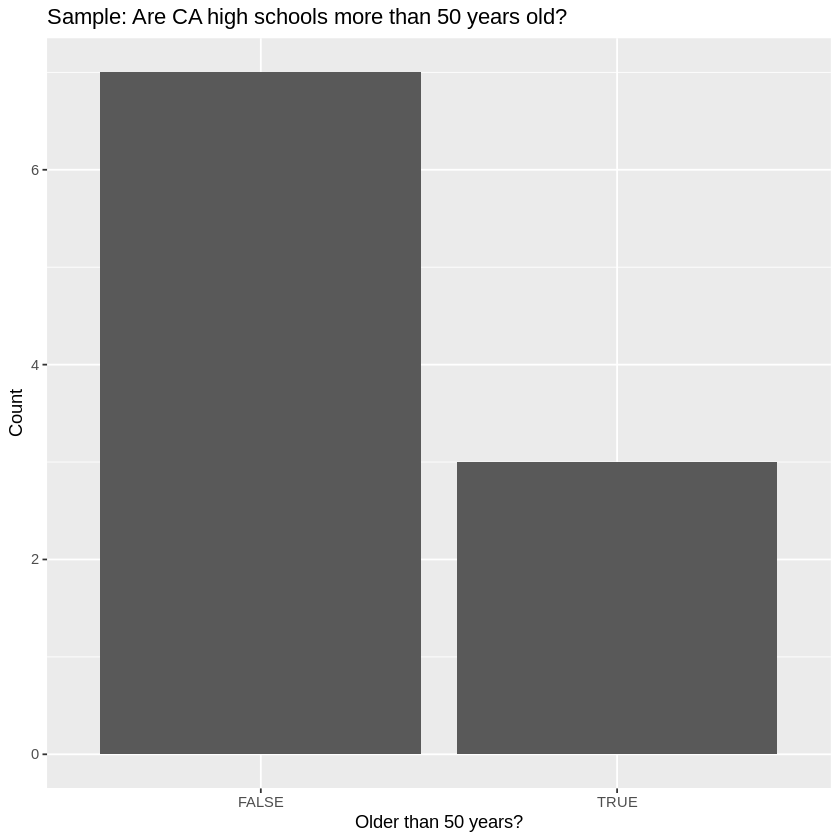

In [ ]:
ggplot(data.frame(old50 = old50), aes(x = old50)) +
  geom_bar() +
  labs(
    title = "Sample: Are CA high schools more than 50 years old?",
    x = "Older than 50 years?",
    y = "Count"
  )


## Step 4 — Report x, n, and p-hat

- \(n\) = sample size  
- \(x\) = number of schools older than 50 years  
- \(\hat p = x/n\) = sample proportion


In [ ]:
sum(old50)       # x
length(old50)    # n
mean(old50)      # p-hat


[1] 3

[1] 10

[1] 0.3

## Step 5 — 95% CI for the proportion (normal approximation + FPC)

For an SRS without replacement from a finite population of size N, the **finite population correction** is:


This is the **normal-approximation** CI. It works best when the sample is not too small and when
$n\hat p$ and $n(1-\hat p)$ are not tiny (e.g. greater than 10).

The code below returns: `c(lower, upper)`.


In [ ]:
p_hat <- mean(old50)
n <- length(old50)

p_hat + c(-1, 1) * qnorm(0.975) *
  sqrt(p_hat * (1 - p_hat) / n) *
  sqrt((N - n) / (N - 1))


[1] 0.01676625 0.58323375

## Step 6 — 95% CI using a high-level method (`survey` package)

Here we:
1. Put the binary data into a data frame
2. Create a survey design for an SRS with a known finite population size (via `fpc`)
3. Use `svymean()` to estimate the proportion (mean of a 0/1 variable)
4. Use `confint()` to get a 95% CI

Tip: `svymean(~old50, ...)` treats `old50` as 0/1 internally.


In [ ]:
library(survey)

df <- data.frame(old50 = old50)
df$fpc <- rep(N, nrow(df))

des <- svydesign(ids = ~1, data = df, fpc = ~fpc)

m <- svymean(~old50, des)
m
confint(m)  # 95% CI by default


Loading required package: grid

Loading required package: Matrix

Loading required package: survival


Attaching package: ‘survey’


The following object is masked from ‘package:graphics’:

    dotchart




           mean     SE
old50FALSE  0.7 0.1523
old50TRUE   0.3 0.1523

,2.5 %,97.5 %
old50FALSE,0.401537748,0.9984623
old50TRUE,0.001537748,0.5984623


## Step 7 — Interpretation template

> “Based on this simple random sample of \(n\) CA high schools, I’m 95% confident that the true proportion of **all \(N\)** CA high schools that are **more than 50 years old** (in 2024) is between **L** and **U**.”

Copy **L** and **U** from either CI method.
